In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 9.14MB/s]

Extracting files...
Path to dataset files: C:\Users\joaqu\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1


In [2]:
import os

# look at all data files
print(os.listdir(path))

['UCI_Credit_Card.csv']


In [ ]:
# ebuild full path and load it
file_name = "UCI_Credit_Card.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

## DATA CLEANING

In [7]:
# initial inspection of data frame
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

In [8]:
# check missing values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

- Pay close attention to default.payment.next.month, PAY_AMT2, and EDUCATION for possible issues
- drop ID as it gives no predictive power (index variable)
- no missing values or non-plausible values in the data
- categorical variables are already in numerical form. no need to format

In [22]:
# drop ID column
df = df.drop('ID', axis=1)

In [9]:
# rename columns for clarity
df = df.rename(columns={
    "default.payment.next.month": "default",
    "PAY_0": "PAY_1"
})

In [10]:
# remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
# merge 0, 5, and 6 since they are both "unknown" category
# keep "unknown" separate from "other"
df["EDUCATION"] = df["EDUCATION"].replace({0: 5, 5: 5, 6: 5})

# verify
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      345
4      123
Name: count, dtype: int64

In [13]:
# MARRIAGE cleanup
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

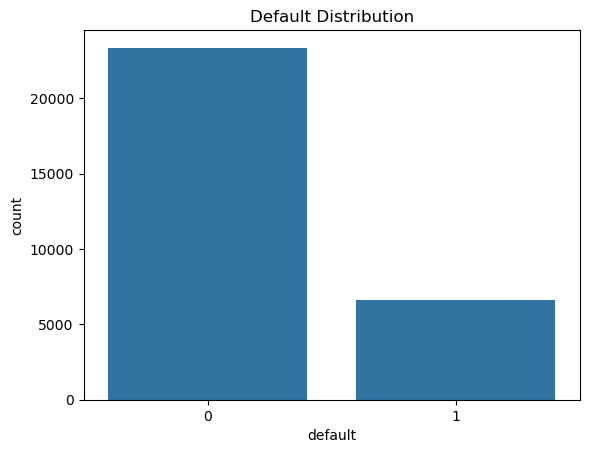

In [14]:
# check target variable distribution
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

- target variable imbalance. address inmediately to avoid bias in the model
- use resampling technique or other

In [ ]:
# understand class imbalance
df["default"].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

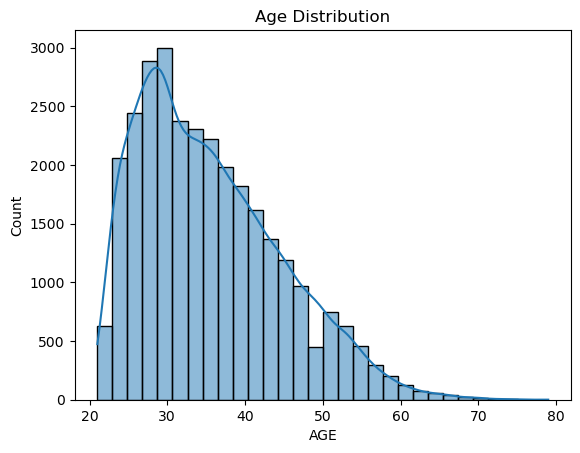

In [15]:
# AGE distribution
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

- skewness to the right. consider transformation

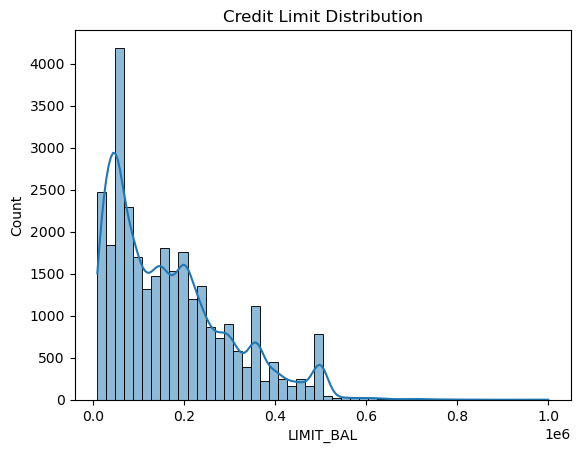

In [16]:
# credit limit distribution
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True)
plt.title("Credit Limit Distribution")
plt.show()

- once again skewness to the right. consdier transformation.
- more unstable than age distribution

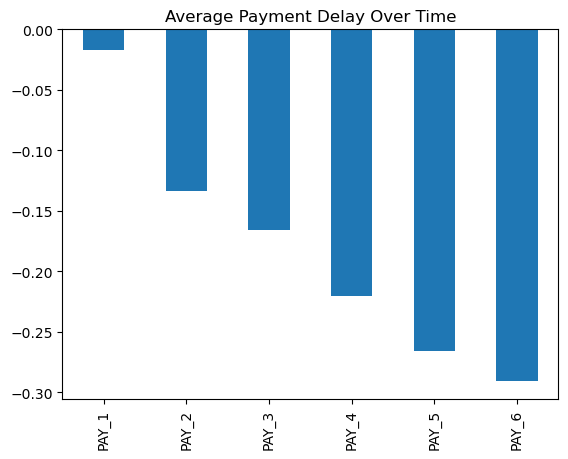

In [17]:
# payment status each month analysis
pay_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

df[pay_cols].mean().plot(kind="bar")
plt.title("Average Payment Delay Over Time")
plt.show()

- this graph tells us that loaners tend to struggle more and more as they grow debt continuously each month

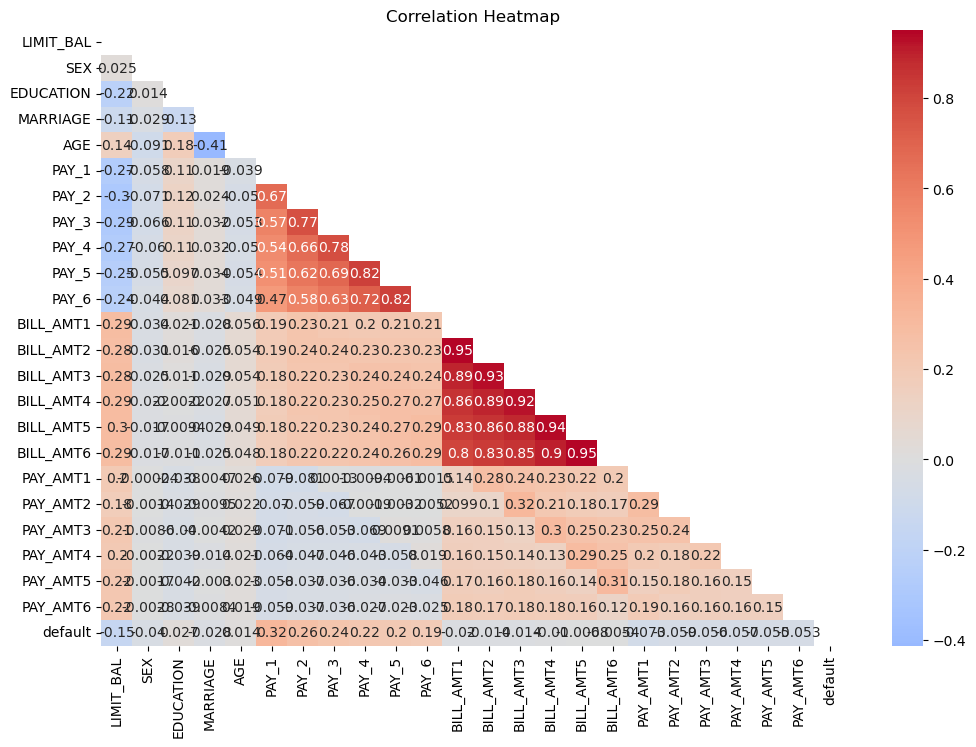

In [23]:
# heatmap correlation
plt.figure(figsize=(12,8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

- be mindful of potential multicollinearity issues.
- high correlation between features makes it impossible to determine the individual importance of variables. interpretability problem


## FEATURE ENGINEERING

In [24]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
            "BILL_AMT4","BILL_AMT5","BILL_AMT6"]

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

In [25]:
# total bill amount
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

In [26]:
# total payment amount
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)

In [27]:
# payment ratio (signal)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1) # +1 to avoid division by 0

In [28]:
# credit utilization (debt to limit percentage)
df["UTILIZATION"] = df["TOTAL_BILL"] / (df["LIMIT_BAL"] + 1)

In [29]:
# log transform for skewed variables
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])
df["AGE_LOG"] = np.log1p(df["AGE"])

In [ ]:
# save csv of clean dataset
import os

folder_path = r"C:\Users\joaqu\OneDrive\Documents\Stat Fnd 2"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")

In [41]:
df.to_csv(file_path, index=False)

In [42]:
print(os.listdir(folder_path))

['Assignment1 Joaquin Hidalgo.ipynb', 'Assignment2 Joaquin Hidalgo.ipynb', 'Assignment3 Joaquin Hidalgo.ipynb', 'cleaned_credit_data_v1.csv', 'HW1_Joaquin_Hidalgo.pdf', 'HW3_Joaquin_Hidalgo.pdf']
